# Regional model scorecard

A compact, ExtremeWeatherBench-style scorecard for daily-mean temperature and deterministic q95 hot-day forecasts. Cells show each model's **absolute** score; their color shows relative performance against the configured reference.

Hot days are ERA5 local-solar daily-mean temperatures above the ERA5 1991–2020 q95 threshold. For POD and FAR, every model is made deterministic by testing its forecast temperature against that same local-day threshold. `aifs_ens_v2` therefore uses its **ensemble-mean temperature**, not individual members or ensemble exceedance probability.

Definitions: POD = hits / (hits + misses); FAR = false alarms / (hits + false alarms). All regional statistics use cosine-latitude area weighting.

In [13]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from matplotlib.patches import Rectangle
import cartopy.crs as ccrs
from dask.diagnostics import ProgressBar

import heatextremes.verification.case_cache_reader as reader
from heatextremes.verification.alignment import map_to_forecast_grid


In [55]:
# --- Scorecard configuration: edit these lists/dictionaries as needed. ---
MODEL_NAMES = [
    'aifs_ens_v2',  # Reference: reader returns its ensemble-mean temperature.
    'ifs_ens',
    'aifs_v2',
    'aurora_e2s',
    'graphcast_e2s',
]
MODEL_LABELS = {
    'aifs_ens_v2': 'AIFS ENS\nv2 mean\n',
    'ifs_ens': 'ECMWF IFS\nENS',
    'aifs_v2': 'AIFS v2',
    'aurora_e2s': 'Aurora',
    'graphcast_e2s': 'GraphCast',
}
REFERENCE_MODEL = 'aifs_ens_v2'

# Start in synthetic mode to workshop the figure locally. Set to 'real'
# to open/cache real model intermediates and calculate the same scorecard.
DATA_MODE = 'real'  # 'synthetic' or 'real'
SYNTHETIC_SEED = 42

SCORECARD_METRICS = ['rmse_all', 'rmse_hot', 'pod', 'far']
FORECAST_DAYS = [0, 3, 6, 9, 12]
JJAS_MONTHS = [6, 7, 8, 9]
VALIDATION_YEARS = [2022, 2023, 2024, 2025]
CLIMATOLOGY_YEARS = list(range(1991, 2021))
CALCULATE_CLIMATOLOGY_RMSE = True  # Calendar-day mean temperature baseline.
LEGACY_AIFS_YEARS = [2022, 2023, 2024, 2025]

# One scorecard row per non-seam-crossing latitude/longitude box.
REGIONS = [
    #{
    #    'name': 'East Africa',
    #    'bounds': {'latitude': (-15.0, 20.0), 'longitude': (25.0, 55.0)},
    #},
    #{
    #    'name': 'South Asia',
        # Rectangular approximation around India and Bangladesh.
    #    'bounds': {'latitude': (6.0, 30.0), 'longitude': (68.0, 93.0)},
    #},
    {
        'name': 'West Africa',
        'bounds': { 'latitude': (-10.0, 25.0), 'longitude': (-20.0, 20.0)}
    }
]

# Use common initializations so every model is evaluated on the same dates.
# Set False only for exploratory, model-specific coverage diagnostics.
COMMON_INITIALIZATIONS = True

THRESHOLD_STORE = (
    '/net/monsoon/kylehall/ERA5/heat_extremes_climatology/'
    'thresholds/t2m_daily_mean_percentiles_1991_2020.zarr'
)
THRESHOLD_VARIABLE = 't2m_daily_mean_calendar_day_percentile'
# This store supplies the calendar-day (15-day rolling) climatological threshold.
THRESHOLD_PERCENTILE = 95.0

assert REFERENCE_MODEL in MODEL_NAMES
assert DATA_MODE in {'synthetic', 'real'}
assert all({'name', 'bounds'} <= set(region) for region in REGIONS)
assert set(SCORECARD_METRICS) <= {'rmse_all', 'rmse_hot', 'pod', 'far'}
assert isinstance(CALCULATE_CLIMATOLOGY_RMSE, bool)
assert all(0 <= day <= 14 for day in FORECAST_DAYS)


In [29]:
def coordinate_slice(coordinate, lower, upper):
    """Return a latitude/longitude slice for either coordinate direction."""
    return slice(lower, upper) if coordinate.values[0] < coordinate.values[-1] else slice(upper, lower)


def select_region(values, region):
    """Subset a non-seam-crossing latitude/longitude box."""
    return values.sel(
        latitude=coordinate_slice(values.latitude, *region['latitude']),
        longitude=coordinate_slice(values.longitude, *region['longitude']),
    )


def select_percentile(field, percentile):
    """Select a percentile regardless of the store's coordinate spelling."""
    for name in ('percentiles', 'percentile', 'quantile'):
        if name in field.dims or name in field.coords:
            return field.sel({name: percentile}, method='nearest', drop=True)
    return field


def local_day_threshold(lead, threshold):
    """Match the q95 threshold to each lead's longitude-specific valid date."""
    forecast = lead['forecast_temperature']
    threshold = map_to_forecast_grid(threshold, forecast, method='linear')
    valid_date = lead['valid_date']
    dayofyear = valid_date.dt.dayofyear.fillna(1).astype(np.int16)
    matched = threshold_for_calendar_days(threshold, dayofyear).where(valid_date.notnull())
    return matched.transpose(*forecast.dims)


def regional_daily_temperature_climatology(daily_temperature, region):
    """1991–2020 calendar-day mean daily temperature for one scorecard region."""
    temperature = select_region(daily_temperature, region)
    historical = temperature.where(
        temperature.time.dt.year.isin(CLIMATOLOGY_YEARS), drop=True
    )
    if not historical.sizes.get('time', 0):
        raise ValueError('No ERA5 daily temperatures found for CLIMATOLOGY_YEARS.')
    return historical.groupby('time.dayofyear').mean('time', skipna=True).rename(
        'daily_temperature_climatology'
    )


def local_day_temperature_climatology(lead, temperature_climatology):
    """Match a calendar-day mean temperature climatology to a lead's valid dates."""
    forecast = lead['forecast_temperature']
    temperature_climatology = map_to_forecast_grid(
        temperature_climatology, forecast, method='linear'
    )
    valid_date = lead['valid_date']
    dayofyear = valid_date.dt.dayofyear.fillna(1).astype(np.int16)
    matched = threshold_for_calendar_days(temperature_climatology, dayofyear)
    return matched.where(valid_date.notnull()).transpose(*forecast.dims)


def threshold_for_calendar_days(threshold, dayofyear):
    """Select a calendar-day field defensively across 0/1-based stores."""
    available = np.asarray(threshold['dayofyear'].values, dtype=np.int16)
    if not len(available):
        raise ValueError('Threshold store has an empty dayofyear coordinate.')
    # Some historical products label a no-leap calendar 0–364 instead of 1–365.
    lookup = dayofyear - 1 if available.min() == 0 else dayofyear
    requested = np.unique(lookup.values[~pd.isnull(lookup.values)])
    missing = np.setdiff1d(requested, available)
    if len(missing):
        reported = getattr(threshold_for_calendar_days, '_reported_mismatches', set())
        key = (tuple(available[[0, -1]]), tuple(missing.tolist()))
        if key not in reported:
            print(
                'Calendar-day field mismatch: available dayofyear '
                f'{available.min()}–{available.max()}, missing requested labels {missing.tolist()}; '
                'using the nearest available calendar-day value for those labels.',
                flush=True,
            )
            threshold_for_calendar_days._reported_mismatches = reported | {key}
        return threshold.sel(dayofyear=lookup, method='nearest')
    return threshold.sel(dayofyear=lookup)


def regional_weights(values):
    return xr.DataArray(
        np.cos(np.deg2rad(values.latitude)),
        dims=('latitude',),
        coords={'latitude': values.latitude},
    )


def reduction_dims(values):
    return tuple(name for name in ('initialization', 'latitude', 'longitude') if name in values.dims)


def weighted_support(mask, weights):
    return weights.where(mask).sum(reduction_dims(mask), skipna=True)


def weighted_rmse(error, valid, weights):
    denominator = weighted_support(valid, weights)
    numerator = ((error ** 2) * weights).where(valid).sum(reduction_dims(error), skipna=True)
    return np.sqrt(numerator / denominator)


def score_one_lead(dataset, forecast_day, threshold, region):
    """Compute all requested scores for one model/lead in one Dask computation."""
    lead = select_region(dataset.sel(forecast_day=forecast_day), region)
    threshold = local_day_threshold(lead, threshold)
    weights = regional_weights(lead['forecast_temperature'])

    forecast = lead['forecast_temperature']
    observation = lead['observation_temperature']
    temperature_valid = lead['temperature_case_valid'].fillna(False).astype(bool)
    event_valid = lead['event_case_valid'].sel(event='hot_day_q95').fillna(False).astype(bool)
    observed_hot = lead['observed_event'].sel(event='hot_day_q95') > 0.5

    # POD/FAR deliberately use forecast temperature versus q95, including
    # for AIFS ENS v2: this is an ensemble-mean deterministic forecast.
    deterministic_valid = temperature_valid & event_valid & threshold.notnull()
    forecast_hot = forecast > threshold
    hit = deterministic_valid & forecast_hot & observed_hot
    miss = deterministic_valid & ~forecast_hot & observed_hot
    false_alarm = deterministic_valid & forecast_hot & ~observed_hot

    error = forecast - observation
    hot_temperature_valid = temperature_valid & event_valid & observed_hot
    result = xr.Dataset(
        {
            'rmse_all': weighted_rmse(error, temperature_valid, weights),
            'rmse_hot': weighted_rmse(error, hot_temperature_valid, weights),
            'pod': weighted_support(hit, weights) / (
                weighted_support(hit, weights) + weighted_support(miss, weights)
            ),
            'far': weighted_support(false_alarm, weights) / (
                weighted_support(hit, weights) + weighted_support(false_alarm, weights)
            ),
            'all_cases': temperature_valid.sum(reduction_dims(temperature_valid)),
            'hot_cases': hot_temperature_valid.sum(reduction_dims(hot_temperature_valid)),
            'binary_cases': deterministic_valid.sum(reduction_dims(deterministic_valid)),
        }
    )
    with ProgressBar():
        return result.compute()


def climatology_rmse_one_lead(dataset, forecast_day, temperature_climatology, region):
    """RMSE of a calendar-day mean temperature forecast for one lead."""
    lead = select_region(dataset.sel(forecast_day=forecast_day), region)
    climatology = local_day_temperature_climatology(lead, temperature_climatology)
    observation = lead['observation_temperature']
    valid = lead['temperature_case_valid'].fillna(False).astype(bool) & climatology.notnull()
    weights = regional_weights(observation)
    result = xr.Dataset(
        {
            'climatology_rmse': weighted_rmse(climatology - observation, valid, weights),
            'climatology_cases': valid.sum(reduction_dims(valid)),
        }
    )
    with ProgressBar():
        return result.compute()


def hot_day_frequency_change(daily_temperature, threshold, region):
    """Observed JJAS hot-day-frequency change, validation versus climatology."""
    temperature = select_region(daily_temperature, region)
    threshold = map_to_forecast_grid(threshold, temperature, method='linear')
    threshold_by_day = threshold_for_calendar_days(
        threshold, temperature.time.dt.dayofyear
    )
    observed_hot = temperature > threshold_by_day
    validation = observed_hot.where(
        temperature.time.dt.year.isin(VALIDATION_YEARS)
        & temperature.time.dt.month.isin(JJAS_MONTHS)
    ).mean('time', skipna=True)
    climatology = observed_hot.where(
        temperature.time.dt.year.isin(CLIMATOLOGY_YEARS)
        & temperature.time.dt.month.isin(JJAS_MONTHS)
    ).mean('time', skipna=True)
    return (100 * (validation / climatology - 1)).rename('hot_day_frequency_change')


In [16]:
# The reader opens Zarr metadata lazily and reports missing month/lead slices.
datasets = {}
threshold_source = None
threshold_q95 = None
daily_temperature_source = None
era5_daily_temperature = None

if DATA_MODE == 'real':
    for model_name in MODEL_NAMES:
        print(f'Opening {model_name}…', flush=True)
        kwargs = {'forecast_days': FORECAST_DAYS}
        if model_name.casefold() in reader.LEGACY_AIFS_MODEL_NAMES:
            kwargs.update(years=LEGACY_AIFS_YEARS, months=JJAS_MONTHS)
        dataset = reader.open_model_intermediates(model_name, **kwargs)
        datasets[model_name] = dataset.sel(
            initialization=dataset.initialization.dt.month.isin(JJAS_MONTHS)
        )

    if COMMON_INITIALIZATIONS:
        common_initializations = datasets[MODEL_NAMES[0]].initialization.values
        for model_name in MODEL_NAMES[1:]:
            common_initializations = np.intersect1d(
                common_initializations, datasets[model_name].initialization.values
            )
        if not len(common_initializations):
            raise ValueError(
                'The selected models have no common initialization dates. '
                'Inspect their inventories or set COMMON_INITIALIZATIONS=False for coverage diagnostics.'
            )
        print(f'Using {len(common_initializations)} common JJAS initializations.', flush=True)
        datasets = {
            model_name: dataset.sel(initialization=common_initializations)
            for model_name, dataset in datasets.items()
        }

    threshold_source = xr.open_zarr(THRESHOLD_STORE, consolidated=True, chunks='auto')
    threshold_q95 = select_percentile(
        threshold_source[THRESHOLD_VARIABLE], THRESHOLD_PERCENTILE
    )
    daily_temperature_source = xr.open_zarr(
        reader.DEFAULT_ERA5_DAILY_TEMPERATURE_STORE, consolidated=True, chunks='auto'
    )
    era5_daily_temperature = daily_temperature_source['t2m_daily_mean']
else:
    print('Synthetic mode: skipping intermediate-reader and ERA5 access.', flush=True)


Opening aifs_ens_v2…
[intermediate-reader] Legacy AIFS monthly: 16 store(s), forecast days [0, 3, 6, 9, 12], root=/net/monsoon/kylehall/ERA5/heat_extremes_aifs_ens_v2/monthly
[intermediate-reader] [1/16] Opening 2022-06: /net/monsoon/kylehall/ERA5/heat_extremes_aifs_ens_v2/monthly/2022/aifs_ens_v2_heat_202206.zarr


[intermediate-reader] [1/16] 2022-06: ready (5/5 leads)
[intermediate-reader] [2/16] Opening 2022-07: /net/monsoon/kylehall/ERA5/heat_extremes_aifs_ens_v2/monthly/2022/aifs_ens_v2_heat_202207.zarr
[intermediate-reader] [2/16] 2022-07: ready (5/5 leads)
[intermediate-reader] [3/16] Opening 2022-08: /net/monsoon/kylehall/ERA5/heat_extremes_aifs_ens_v2/monthly/2022/aifs_ens_v2_heat_202208.zarr
[intermediate-reader] [3/16] 2022-08: ready (5/5 leads)
[intermediate-reader] [4/16] Opening 2022-09: /net/monsoon/kylehall/ERA5/heat_extremes_aifs_ens_v2/monthly/2022/aifs_ens_v2_heat_202209.zarr
[intermediate-reader] [4/16] 2022-09: ready (5/5 leads)
[intermediate-reader] [5/16] Opening 2023-06: /net/monsoon/kylehall/ERA5/heat_extremes_aifs_ens_v2/monthly/2023/aifs_ens_v2_heat_202306.zarr
[intermediate-reader] [5/16] 2023-06: ready (5/5 leads)
[intermediate-reader] [6/16] Opening 2023-07: /net/monsoon/kylehall/ERA5/heat_extremes_aifs_ens_v2/monthly/2023/aifs_ens_v2_heat_202307.zarr
[intermediate-r

In [17]:
def synthetic_scorecard(seed):
    """Create fixed, plausible score patterns solely for layout work."""
    rng = np.random.default_rng(seed)
    baseline = {
        'rmse_all': np.linspace(1.6, 4.2, len(FORECAST_DAYS)),
        'rmse_hot': np.linspace(1.9, 4.8, len(FORECAST_DAYS)),
        'pod': np.linspace(0.78, 0.46, len(FORECAST_DAYS)),
        'far': np.linspace(0.18, 0.43, len(FORECAST_DAYS)),
    }
    # Relative skill versus AIFS ENS v2 mean: negative is better for
    # lower-is-better metrics; positive is better for POD.
    relative_skill = {
        'aifs_ens_v2': 0.00,
        'ifs_ens': -0.03,
        'aifs_v2': -0.06,
        'aurora_e2s': 0.05,
        'graphcast_e2s': -0.02,
    }
    rows = []
    for region_index, region in enumerate(REGIONS):
        for model_name in MODEL_NAMES:
            for lead_index, forecast_day in enumerate(FORECAST_DAYS):
                skill = relative_skill.get(model_name, 0.0) + rng.normal(0, 0.025)
                row = {
                    'region': region['name'],
                    'model': model_name,
                    'model_label': MODEL_LABELS.get(model_name, model_name),
                    'forecast_day': forecast_day,
                    'all_cases': int(42000 - 4500 * region_index - 900 * lead_index),
                    'hot_cases': int(2200 - 300 * region_index - 80 * lead_index),
                    'binary_cases': int(41500 - 4500 * region_index - 900 * lead_index),
                }
                for metric in SCORECARD_METRICS:
                    value = baseline[metric][lead_index]
                    if metric.startswith('rmse'):
                        value *= 1 + 0.12 * region_index
                    elif metric == 'pod':
                        value *= 1 - 0.05 * region_index
                    else:
                        value *= 1 + 0.12 * region_index
                    value *= 1 + skill
                    row[metric] = float(np.clip(value, 0.01, 0.99) if metric in {'pod', 'far'} else value)
                rows.append(row)
    return pd.DataFrame(rows).sort_values(['region', 'model', 'forecast_day'])


def synthetic_climatology_rmse(seed):
    """Toy calendar-day climatology RMSE for the standalone sanity-check plot."""
    rng = np.random.default_rng(seed + 2)
    rows = []
    for region_index, region in enumerate(REGIONS):
        for lead_index, forecast_day in enumerate(FORECAST_DAYS):
            rows.append(
                {
                    'region': region['name'],
                    'forecast_day': forecast_day,
                    'climatology_rmse': 3.55 + 0.20 * region_index + rng.normal(0, 0.04),
                    'climatology_cases': int(42000 - 4500 * region_index - 900 * lead_index),
                }
            )
    return pd.DataFrame(rows).sort_values(['region', 'forecast_day'])


def synthetic_hot_day_frequency_change(seed):
    """Create toy observed hot-day-frequency changes, in percent."""
    rng = np.random.default_rng(seed + 1)
    fields = {}
    for index, region in enumerate(REGIONS):
        bounds = region['bounds']
        latitude = np.linspace(*bounds['latitude'], 42)
        longitude = np.linspace(*bounds['longitude'], 50)
        lon, lat = np.meshgrid(longitude, latitude)
        broad_pattern = (
            20 * np.sin((lon - longitude.mean()) / 6)
            + 13 * np.cos((lat - latitude.mean()) / 5)
            + 8 * index
        )
        noise = rng.normal(0, 4, size=broad_pattern.shape)
        fields[region['name']] = xr.DataArray(
            broad_pattern + noise,
            dims=('latitude', 'longitude'),
            coords={'latitude': latitude, 'longitude': longitude},
            name='hot_day_frequency_change',
            attrs={
                'long_name': 'Observed hot-day frequency change',
                'units': '%',
                'definition': '100 * (2022–2025 JJAS exceedance frequency / 1991–2020 JJAS exceedance frequency - 1)',
            },
        )
    return fields


if DATA_MODE == 'synthetic':
    scorecard = synthetic_scorecard(SYNTHETIC_SEED)
    climatology_benchmark = synthetic_climatology_rmse(SYNTHETIC_SEED)
    frequency_change_maps = synthetic_hot_day_frequency_change(SYNTHETIC_SEED)
else:
    # One bounded computation per model and lead keeps memory use predictable.
    score_rows = []
    for region in REGIONS:
        for model_name, dataset in datasets.items():
            for forecast_day in FORECAST_DAYS:
                print(f"Computing {region['name']}: {model_name}, forecast day {forecast_day}…", flush=True)
                result = score_one_lead(dataset, forecast_day, threshold_q95, region['bounds'])
                score_rows.append(
                    {
                        'region': region['name'],
                        'model': model_name,
                        'model_label': MODEL_LABELS.get(model_name, model_name),
                        'forecast_day': forecast_day,
                        **{name: float(result[name]) for name in SCORECARD_METRICS},
                        'all_cases': int(result['all_cases']),
                        'hot_cases': int(result['hot_cases']),
                        'binary_cases': int(result['binary_cases']),
                    }
                )
    scorecard = pd.DataFrame(score_rows).sort_values(['region', 'model', 'forecast_day'])

    climatology_rows = []
    if CALCULATE_CLIMATOLOGY_RMSE:
        # Compute the historical mean only over each selected region, then
        # score it on the reference model's valid target dates.  With common
        # initializations this is directly comparable to every model row.
        for region in REGIONS:
            print(f"Building 1991–2020 daily climatology for {region['name']}…", flush=True)
            with ProgressBar():
                temperature_climatology = regional_daily_temperature_climatology(
                    era5_daily_temperature, region['bounds']
                ).compute()
            for forecast_day in FORECAST_DAYS:
                print(
                    f"Computing {region['name']}: calendar-day climatology, "
                    f"forecast day {forecast_day}…",
                    flush=True,
                )
                result = climatology_rmse_one_lead(
                    datasets[REFERENCE_MODEL],
                    forecast_day,
                    temperature_climatology,
                    region['bounds'],
                )
                climatology_rows.append(
                    {
                        'region': region['name'],
                        'forecast_day': forecast_day,
                        'climatology_rmse': float(result['climatology_rmse']),
                        'climatology_cases': int(result['climatology_cases']),
                    }
                )
    climatology_benchmark = pd.DataFrame(climatology_rows)
    frequency_change_maps = {
        region['name']: hot_day_frequency_change(
            era5_daily_temperature, threshold_q95, region['bounds']
        )
        for region in REGIONS
    }


if CALCULATE_CLIMATOLOGY_RMSE:
    scorecard = scorecard.merge(
        climatology_benchmark[['region', 'forecast_day', 'climatology_rmse']],
        on=['region', 'forecast_day'],
        how='left',
        validate='many_to_one',
    )
    # Below one means the model beats the historical calendar-day mean.
    scorecard['rmse_fraction_of_climatology'] = (
        scorecard['rmse_all'] / scorecard['climatology_rmse']
    )

scorecard


Computing West Africa: aifs_ens_v2, forecast day 0…
[########################################] | 100% Completed | 36.72 s
Computing West Africa: aifs_ens_v2, forecast day 3…
[########################################] | 100% Completed | 35.60 s
Computing West Africa: aifs_ens_v2, forecast day 6…
[########################################] | 100% Completed | 30.18 s
Computing West Africa: aifs_ens_v2, forecast day 9…
[########################################] | 100% Completed | 34.51 s
Computing West Africa: aifs_ens_v2, forecast day 12…
[########################################] | 100% Completed | 30.53 s
Computing West Africa: aifs_v2, forecast day 0…
[########################################] | 100% Completed | 33.39 s
Computing West Africa: aifs_v2, forecast day 3…
[########################################] | 100% Completed | 30.71 s
Computing West Africa: aifs_v2, forecast day 6…
[########################################] | 100% Completed | 28.20 s
Computing West Africa: aifs_v2, for

,region,model,model_label,forecast_day,rmse_all,rmse_hot,pod,far,all_cases,hot_cases,binary_cases
0,West Africa,aifs_ens_v2,AIFS ENS\nv2 mean,0,0.848735,1.075723,0.414969,0.293842,1370520,194649,1370520
1,West Africa,aifs_ens_v2,AIFS ENS\nv2 mean,3,0.928722,1.191043,0.345754,0.347116,1370520,178107,1370520
2,West Africa,aifs_ens_v2,AIFS ENS\nv2 mean,6,0.959235,1.269058,0.310225,0.394915,1370520,201313,1370520
3,West Africa,aifs_ens_v2,AIFS ENS\nv2 mean,9,1.068093,1.472513,0.234328,0.385172,1370520,206179,1370520
4,West Africa,aifs_ens_v2,AIFS ENS\nv2 mean,12,1.126945,1.608129,0.181086,0.444015,1370520,212737,1370520
5,West Africa,aifs_v2,AIFS v2,0,0.954681,1.320079,0.234914,0.187768,1370520,194649,1370520
6,West Africa,aifs_v2,AIFS v2,3,1.123005,1.597362,0.183797,0.382700,1370520,178107,1370520
7,West Africa,aifs_v2,AIFS v2,6,1.213815,1.690716,0.180759,0.501786,1370520,201313,1370520
8,West Africa,aifs_v2,AIFS v2,9,1.337312,1.815551,0.183792,0.615445,1370520,206179,1370520
9,West Africa,aifs_v2,AIFS v2,12,1.466888,1.951407,0.195603,0.657265,1290573,210577,1290573


In [30]:
# Sanity check: a model should normally lie below this historical-mean baseline.
# The dashed line is scored on the reference model's valid target dates.
if CALCULATE_CLIMATOLOGY_RMSE and not climatology_benchmark.empty:
    sanity_columns = [
        'region', 'model_label', 'forecast_day', 'rmse_all',
        'climatology_rmse', 'rmse_fraction_of_climatology',
    ]
    display(
        scorecard[sanity_columns]
        .sort_values(['region', 'model_label', 'forecast_day'])
        .style.format(
            {
                'rmse_all': '{:.2f}',
                'climatology_rmse': '{:.2f}',
                'rmse_fraction_of_climatology': '{:.2f}',
            }
        )
    )

    figure, axes = plt.subplots(
        1, len(REGIONS), figsize=(6.2 * len(REGIONS), 4.3),
        sharey=True, constrained_layout=True, squeeze=False,
    )
    model_colors = {
        model_name: plt.colormaps['tab10'](index)
        for index, model_name in enumerate(MODEL_NAMES)
    }

    for axis, region in zip(axes.flat, REGIONS):
        region_name = region['name']
        region_scores = scorecard.loc[scorecard['region'].eq(region_name)]
        for model_name in MODEL_NAMES:
            model_scores = region_scores.loc[region_scores['model'].eq(model_name)]
            axis.plot(
                model_scores['forecast_day'], model_scores['rmse_all'],
                marker='o', linewidth=2, color=model_colors[model_name],
                label=MODEL_LABELS.get(model_name, model_name).replace('\n', ' '),
            )

        baseline = climatology_benchmark.loc[
            climatology_benchmark['region'].eq(region_name)
        ]
        axis.plot(
            baseline['forecast_day'], baseline['climatology_rmse'],
            color='#111827', linestyle='--', linewidth=2.2,
            label='1991–2020 daily climatology',
        )
        axis.set(
            title=region_name, xlabel='Forecast day',
            xticks=FORECAST_DAYS,
        )
        axis.grid(alpha=0.25)

    axes.flat[0].set_ylabel('Area-weighted all-day RMSE (K)')
    axes.flat[-1].legend(loc='best', frameon=False, fontsize=8)
    figure.suptitle('RMSE sanity check: models versus daily climatology', fontweight='semibold')
    plt.show()
else:
    print('Set CALCULATE_CLIMATOLOGY_RMSE = True to run this sanity check.')


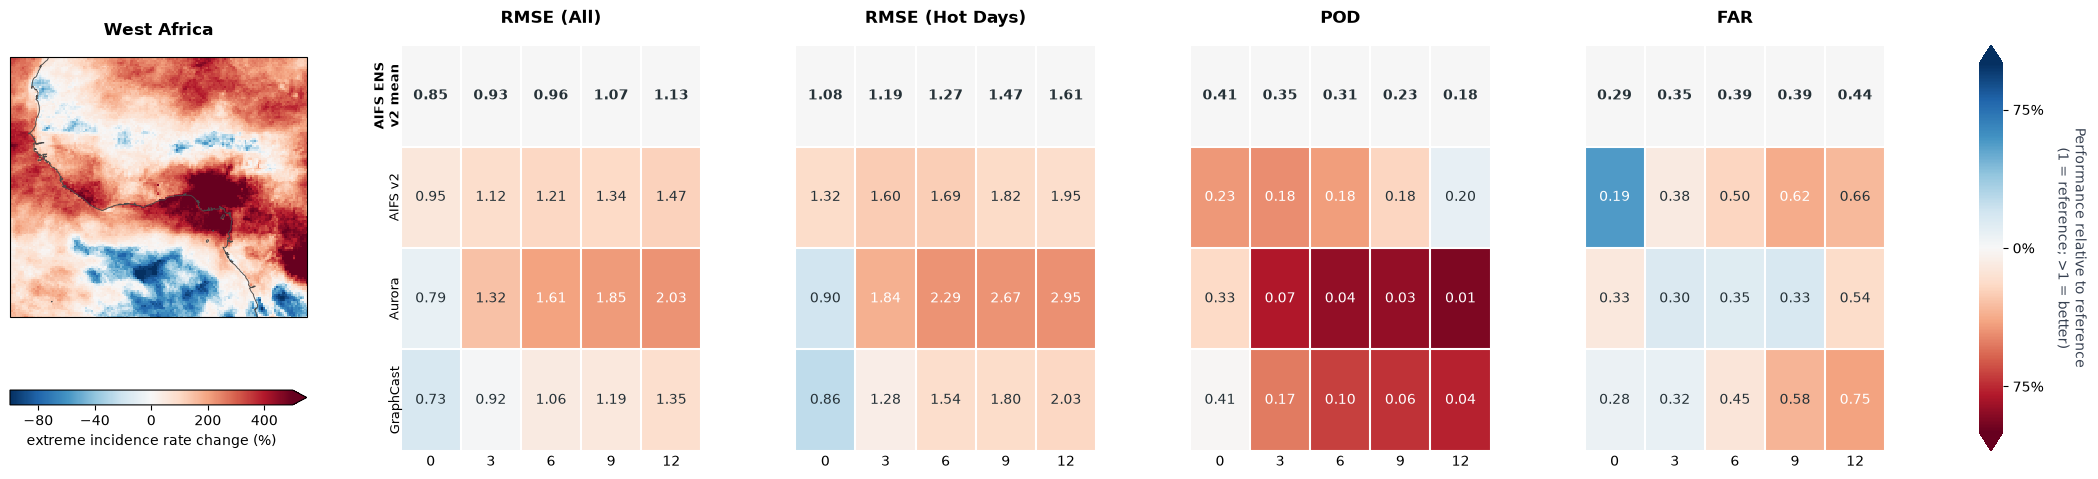

In [60]:
from matplotlib.cm import ScalarMappable
from matplotlib.colors import TwoSlopeNorm
from matplotlib.ticker import FixedLocator, FuncFormatter


METRIC_HIGHER_IS_BETTER = {
    "rmse_all": False,
    "rmse_hot": False,
    "pod": True,
    "far": False,
}

def relative_performance(values, reference_model, metric):
    """
    1.0 = equal to reference
    >1  = better than reference
    <1  = worse than reference
    """
    reference = values.loc[reference_model]

    if METRIC_HIGHER_IS_BETTER[metric]:
        relative = values.divide(reference, axis="columns")
    else:
        relative = values.rdiv(reference, axis="columns")

    return relative.replace([np.inf, -np.inf], np.nan)

def plot_scorecard(frame, frequency_change_maps):
    # --------------------------------------------------------------
    # Independent color scales
    # --------------------------------------------------------------
    map_norm = TwoSlopeNorm(
        vmin=-100,
        vcenter=0,
        vmax=500,
    )
    map_cmap = plt.colormaps["RdBu_r"].copy()
    map_cmap.set_bad("#e5e7eb")

    # 1.0 = reference; >1.0 = better; <1.0 = worse.
    cell_norm = TwoSlopeNorm(
        vmin=-1.0,
        vcenter=0.0,
        vmax=1.0,
    )
    cell_cmap = plt.colormaps["RdBu"].copy()
    cell_cmap.set_bad("#e5e7eb")

    n_regions = len(REGIONS)
    n_metrics = len(SCORECARD_METRICS)

    figure = plt.figure(
        figsize=(
            8.5 + 3.35 * n_metrics,
            1.8 + 3.15 * n_regions,
        ),
        facecolor="white",
    )

    # Rows:
    #   one row per region
    #   one short final row for the map colorbar
    #
    # Columns:
    #   map
    #   metric tables
    #   scorecard colorbar
    grid = figure.add_gridspec(
        n_regions,
        n_metrics + 2,
        width_ratios=[
            1.50,                       # maps
            *([1.52] * n_metrics),      # metric tables
            0.12,                       # scorecard colorbar
        ],
        wspace=0.37,
        hspace=0.45,
    )

    map_axes = []
    metric_axes = []

    for region_index, region in enumerate(REGIONS):
        region_name = region["name"]

        region_frame = frame.loc[
            frame["region"].eq(region_name)
        ]

        bounds = region["bounds"]

        # ==========================================================
        # Map
        # ==========================================================
        map_axis = figure.add_subplot(
            grid[region_index, 0],
            projection=ccrs.PlateCarree(),
        )

        map_axis.set_extent(
            [
                *bounds["longitude"],
                *bounds["latitude"],
            ],
            crs=ccrs.PlateCarree(),
        )

        map_axis.set_facecolor("#f5f7fa")

        map_axes.append(map_axis)

        frequency_change_maps[
            region_name
        ].plot.pcolormesh(
            ax=map_axis,
            transform=ccrs.PlateCarree(),
            cmap=map_cmap,
            norm=map_norm,
            add_colorbar=True,
            cbar_kwargs = {
                'orientation': 'horizontal',
                'label': "extreme incidence rate change (%)",
                'ticks': [-80, -40, 0, 200, 400]
            },
            rasterized=True,
        )

        map_axis.coastlines(
            color="#4a4a4a",
            linewidth=0.65,
        )

        map_axis.spines["geo"].set_visible(True)
        map_axis.spines["geo"].set_color("black")
        map_axis.spines["geo"].set_linewidth(0.8)

        # Cartopy may shrink the map within its allocated grid cell.
        # Anchoring north keeps its top aligned with the tables.
        map_axis.set_anchor("C")

        map_axis.set_title(
            region_name,
            fontsize=12,
            fontweight="semibold",
            pad=16,
        )

        # ==========================================================
        # Metric tables
        # ==========================================================
        for column, metric in enumerate(
            SCORECARD_METRICS,
            start=1,
        ):
            axis = figure.add_subplot(
                grid[region_index, column]
            )
            if column == 1:
                metric_axes.append(axis)

            values = (
                region_frame
                .pivot(
                    index="model",
                    columns="forecast_day",
                    values=metric,
                )
                .reindex(
                    index=MODEL_NAMES,
                    columns=FORECAST_DAYS,
                )
            )

            relative = relative_performance(
                values,
                REFERENCE_MODEL,
                metric,
            ) -1

            axis.imshow(
                np.ma.masked_invalid(
                    relative.to_numpy()
                ),
                cmap=cell_cmap,
                norm=cell_norm,
                interpolation="none",
                aspect="auto",
                origin="upper",
            )

            axis.set_xlim(
                -0.5,
                len(FORECAST_DAYS) - 0.5,
            )
            axis.set_ylim(
                len(MODEL_NAMES) - 0.5,
                -0.5,
            )

            if region_index == 0:
                axis.set_title(
                    METRIC_TITLES[metric],
                    fontsize=12,
                    fontweight="semibold",
                    pad=16,
                )

            axis.set_xticks(
                range(len(FORECAST_DAYS)),
                FORECAST_DAYS,
                fontsize=10,
            )

            axis.set_yticks(
                range(len(MODEL_NAMES))
            )

            axis.set_yticklabels(
                [
                    MODEL_LABELS.get(name, name)
                    for name in MODEL_NAMES
                ]
                if column == 1
                else [],
                fontsize=9,
                rotation=90,
                va="center",
                ha="center",
            )

            axis.tick_params(
                axis="x",
                length=0,
                pad=3,
            )
            axis.tick_params(
                axis="y",
                length=0,
                pad=4,
            )

            for label, model_name in zip(
                axis.get_yticklabels(),
                MODEL_NAMES,
            ):
                if model_name == REFERENCE_MODEL:
                    label.set_fontweight("bold")

            for spine in axis.spines.values():
                spine.set_visible(False)

            axis.set_xticks(
                np.arange(
                    -0.5,
                    len(FORECAST_DAYS),
                    1,
                ),
                minor=True,
            )

            axis.set_yticks(
                np.arange(
                    -0.5,
                    len(MODEL_NAMES),
                    1,
                ),
                minor=True,
            )

            axis.grid(
                which="minor",
                color="white",
                linewidth=1.5,
            )

            axis.tick_params(
                which="minor",
                bottom=False,
                left=False,
            )

            # Display raw values, while shading by relative performance.
            for row in range(len(MODEL_NAMES)):
                for lead_index in range(
                    len(FORECAST_DAYS)
                ):
                    value = values.iloc[
                        row,
                        lead_index,
                    ]

                    relative_value = relative.iloc[
                        row,
                        lead_index,
                    ]

                    if (
                        np.isfinite(relative_value)
                        and (
                            relative_value < -0.35
                            or relative_value > 0.35
                        )
                    ):
                        text_color = "white"
                    else:
                        text_color = "#263238"

                    axis.text(
                        lead_index,
                        row,
                        format_value(metric, value),
                        ha="center",
                        va="center",
                        color=text_color,
                        fontsize=10,
                        fontweight=(
                            "bold"
                            if MODEL_NAMES[row]
                            == REFERENCE_MODEL
                            else "normal"
                        ),
                    )

    # ==============================================================
    # Right-side scorecard colorbar
    # ==============================================================
    cell_mappable = ScalarMappable(
        norm=cell_norm,
        cmap=cell_cmap,
    )
    cell_mappable.set_array([])

    cell_colorbar_axis = figure.add_subplot(
        grid[:, -1]
    )

    cell_colorbar = figure.colorbar(
        cell_mappable,
        cax=cell_colorbar_axis,
        orientation="vertical",
        extend="both",
    )

    cell_colorbar.set_ticks(
        [ -0.75, 0.0, 0.75 ]
    )

    cell_colorbar.set_ticklabels(
        [  "75%", "0%", "75%" ]
    )

    cell_colorbar.outline.set_visible(False)

    cell_colorbar.set_label(
        "Performance relative to reference\n"
        "(1 = reference; >1 = better)",
        rotation=270,
        labelpad=32,
        color="#374151",
    )

    title = (
        "Synthetic preview"
        if DATA_MODE == "synthetic"
        else ""
    )

    figure.suptitle(
        title,
        fontsize=16,
        fontweight="semibold",
        y=0.98,
    )

    figure.subplots_adjust(
        top=0.90,
        bottom=0.08,
        left=0.05,
        right=0.96,
    )

    plt.show()

plot_scorecard(scorecard, frequency_change_maps)


In [19]:
# Always inspect support before comparing small-sample hot-day scores.
support_columns = ['region', 'model_label', 'forecast_day', 'all_cases', 'hot_cases', 'binary_cases']
display(scorecard[support_columns].sort_values(['region', 'model_label', 'forecast_day']))

# Optional: save the exact numbers that produced the figure.
# scorecard.to_csv('regional_model_scorecard.csv', index=False)

# Close lazy source handles once this notebook no longer needs them.
# if threshold_source is not None:
#     threshold_source.close()
# if daily_temperature_source is not None:
#     daily_temperature_source.close()
# for dataset in datasets.values():
#     dataset.close()


,region,model_label,forecast_day,all_cases,hot_cases,binary_cases
0,West Africa,AIFS ENS\nv2 mean,0,1370520,194649,1370520
1,West Africa,AIFS ENS\nv2 mean,3,1370520,178107,1370520
2,West Africa,AIFS ENS\nv2 mean,6,1370520,201313,1370520
3,West Africa,AIFS ENS\nv2 mean,9,1370520,206179,1370520
4,West Africa,AIFS ENS\nv2 mean,12,1370520,212737,1370520
5,West Africa,AIFS v2,0,1370520,194649,1370520
6,West Africa,AIFS v2,3,1370520,178107,1370520
7,West Africa,AIFS v2,6,1370520,201313,1370520
8,West Africa,AIFS v2,9,1370520,206179,1370520
9,West Africa,AIFS v2,12,1290573,210577,1290573
